# A.I. Lab: Computer Vision and NLP - Machine Learning

Machine learning combines computational and statistical approaches in order to provide inference tools for the machine, which, starting from an initial dataset, is able to improve automatically with experience.
Generally speaking, a machine learning algorithm falls into one of the following categories:
- **Supervised learning:** The training set has labels that represent the corresponding solutions.
- **Unsupervised learning:** The training set is unlabelled.
- **Semi-supervised learning:** The training set has partial/incomplete labels, which must be completed by inference.

One of the main problems of machine learning consists in finding a trade-off between bias (assumption error) and variance (fluctuation error) in the data.
For this reason, the model should avoid underfitting, which happens when the model is too simple to explain the data, and overfitting, which happens when the model explains the training set using a more complicated polynomial that would fail to explain new data.

Generally speaking, machine learning datasets are managed using the *Scikit-Learn* library, which provides all the required tools.
In particular, a dataset is provided as a table whose rows represent the samples, whereas the columns represent the features.

In [ ]:
import seaborn as sns # matplotlib extension
import matplotlib.pyplot as plt # if sns does not work

# Start by loading the iris dataset.
iris = sns.load_dataset("iris")
print(iris.head()) # print the first five lines of the dataframe

# View distribution plots of the dataset.
sns.pairplot(iris, hue="species", height=2)
plt.show() # if sns does not work

Mainly used in discriminative models, classification is a supervised machine learning model that involves data with discrete/qualitative labels. <br>
In this case, the training set is typically built from a portion (typically 70/80%) of the starting dataset, whereas the remaining portion is normally used for the testing stage.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Load the iris dataset and recover the data and labels.
iris = sns.load_dataset("iris")
X_iris = iris.drop("species", axis=1) # the data will be given by the numerical variables of the dataset
y = iris["species"] # the dataset will be labelled using the "species" variable

# Start by creating the training and testing datasets by splitting the data in two groups.
# Generally speaking, it is also possible to specify a "random state" to determine whether the sets will always change.
X_train, X_test, y_train, y_test = train_test_split(X_iris, y, train_size=0.5) # no random state means that the groups will change

# Assuming the data follows a Gaussian distribution, create an instance of the Gaussian Naive Bayes algorithm.
model = GaussianNB() # it is also possible, but not necessary, to specify prior probabilities for the model

# Firstly, train the model by fitting the training dataset.
model.fit(X_train, y_train)

# At this point, use the testing dataset in order to make predictions on the model.
y_prediction = model.predict(X_test)

# It is possible to check the performance of the prediction by comparing the actual labels to the prediction labels.
accuracy = accuracy_score(y_test, y_prediction)
print(accuracy)

# N.B.: It is a good practice to avoid using the exact same data for the training and testing stages

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Start by fixing a random seed for generating the points used in the regression model
rng = np.random.RandomState(42)

# Create the coordinates for the training dataset.
# In this case, assume that 50 points will be used for the training stage.
x = 10 * rng.random(50) # generate the points
y = 2 * x - 1 + rng.rand(50) # place the points over a line

# Prepare the data in a matrix because, for simplicity, Scikit-Learn wants to use points as 2D matrices.
X = x[:, np.newaxis] # add a new dimension to store the data into a matrix

# Create an instance of the regression model.
model = LinearRegression(fit_intercept=True)

# Firstly, train the model by fitting the training dataset.
model.fit(X, y)

# Create new points for the testing dataset and prepare them into a 2D matrix.
x_test = np.linspace(-1, 11) # generate equally distant points
X_test = x_test[:, np.newaxis] # add a new dimension to store the testing points into a matrix
y_prediction = model.predict(X_test)

# Plot the new points in order to check the goodness of the linear regression model.
plt.scatter(x, y)
plt.plot(x_test, y_prediction)
plt.show()

When dealing with supervised learning, it is possible to estimate the goodness of the chosen prediction by using a confusion matrix, which shows both the "true positives", which represent the observations whose predicted label matches the actual label, and the "false positives", which represent the observation whose predicted label does not correspond to the correct label.

0.8240740740740741


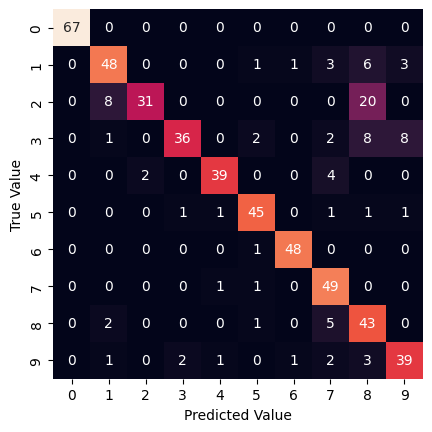

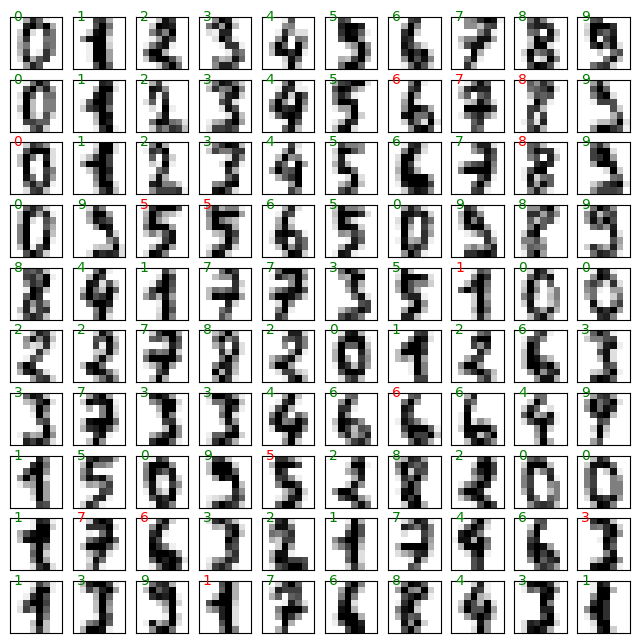

In [1]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Load the digits dataset.
digits = load_digits()

# The shape of the digits dataset does not make it compatible with Scikit-Learn because the samples are two-dimensional.
# However, it is possible to use the data/target attributes in order to get the data without any issues.
X = digits.data # get the samples and the corresponding features
y = digits.target # get the labels

# Start by splitting the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7) # 70% training, 30% testing, no random state

# Assuming the data follow a Guassian distribution, create an instance of the Gaussian Naive Bayes algorithm.
model = GaussianNB()

# Firstly, train the model by fitting the training set.
model.fit(X_train, y_train)

# At this point, use the testing dataset to make predictions with the model.
y_predictions = model.predict(X_test)

# It is possible to check the performance of the prediction by comparing the actual labels to the prediction labels.
accuracy = accuracy_score(y_test, y_predictions)
print(accuracy)

# Generally speaking, it is possible to use a confusion matrix in order to estimate the goodness of the model.
# In addition, the confusion matrix can be used in order to determine the problematic data points as well.
mat = confusion_matrix(y_test, y_predictions)
sns.heatmap(mat, square=True, annot=True, cbar=False) # plot the matrix showing squares and annotations
plt.xlabel("Predicted Value")
plt.ylabel("True Value")
plt.show()

# Plot the pronlematic samples.
figs, axes = plt.subplots(10, 10, figsize=(8, 8), subplot_kw={'xticks':[], 'yticks':[]})
for i,ax in enumerate(axes.flat): # loop over each subplot
    ax.imshow(digits.images[i], cmap='binary') # show the binary images
    ax.text(0.05, 0.05, str(digits.target[i]), color='green' if (y_test[i] == y_predictions[i]) else 'red')
plt.show()

Clustering is an unsupervised machine learning model that, given a training set and k centroids representing the corresponding clusters, tries to map each data point to the respective cluster. <br>
Generaly speaking, clustering is carried out using the K-means algorithm, which, after randomly initializing k centroids from the training set, repeatedly assigns labels and updates centroids until convergence, which happens when the centroids do not change up to some error term.

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Start by loading the iris dataset.
iris = sns.load_dataset("iris")
X_iris = iris.drop("species", axis=1) # take away the categorical label
y_iris = iris["species"] # take the labels, which are not needed as unsupervised learning uses unlabelled points

# Create an instance of the K-means algorithm for clustering.
model = KMeans(n_clusters=3) # instance with 3 clusters

# Train the model by fitting the training dataset.
model.fit(X_iris) # in this case, it is not necessary to split the data as classification does not use the dataset labels
y_predict = model.predict(X_iris) # this allows to determine the cluster number of each data point

# Plot the dataset to check whether the dataset has been correctly clustered.
plt.scatter(X_iris["sepal_length"], X_iris["sepal_width"], c=y_predict) # plot sepal length vs sepal width and distinguish the points by their cluster
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], c="red") # plot the centroids
plt.show()

## Common machine learning models

The Naive Bayes classifier is a supervised generative model build on Bayesian classification, which computes the probability that a testing point is mapped to a label by using Bayes' theorem in the following way: <br>
$$
  \mathbb{P}(L|\text{features}) = \frac{\mathbb{P}(\text{features}|L)\mathbb{P}(L)}{\mathbb{P}(\text{features})}
$$
Therefore, a Naive Bayes classifier aims to find the best generative model for computing $\mathbb{P}(\text{features}|L)$, with the most common choices being Gaussian or Multinomial Naive Bayes according to the assumptions made on the dataset. <br>
Overall, the Naive Bayes classifier is fast and straightforward, although it tends to perform worse compared to other, more complex, classifiers.

Support vector machines are a class of supervised discriminative models that aim to find a line/curve/hyperplane that best divides the data points into classes by maximizing their margins in order to make sure that the classes are as distinguished as possible.